# Radio propagation simulation using mesh-based UTD

In [1]:
%matplotlib inline
import os
import time
import torch
import matplotlib.pyplot as plt

from example_utils import plot_mesh_2d
from rfdt import create_cube_mesh, Tracer, Scene

jitc_llvm_init(): LLVM API initialization failed ..


## Run

Running mesh-based propagation simulation
Mesh: vertices and faces created
[OK] Computed field distribution in 0.93828 seconds
[OK] Figure saved to figures/mesh_2d_detailed.png


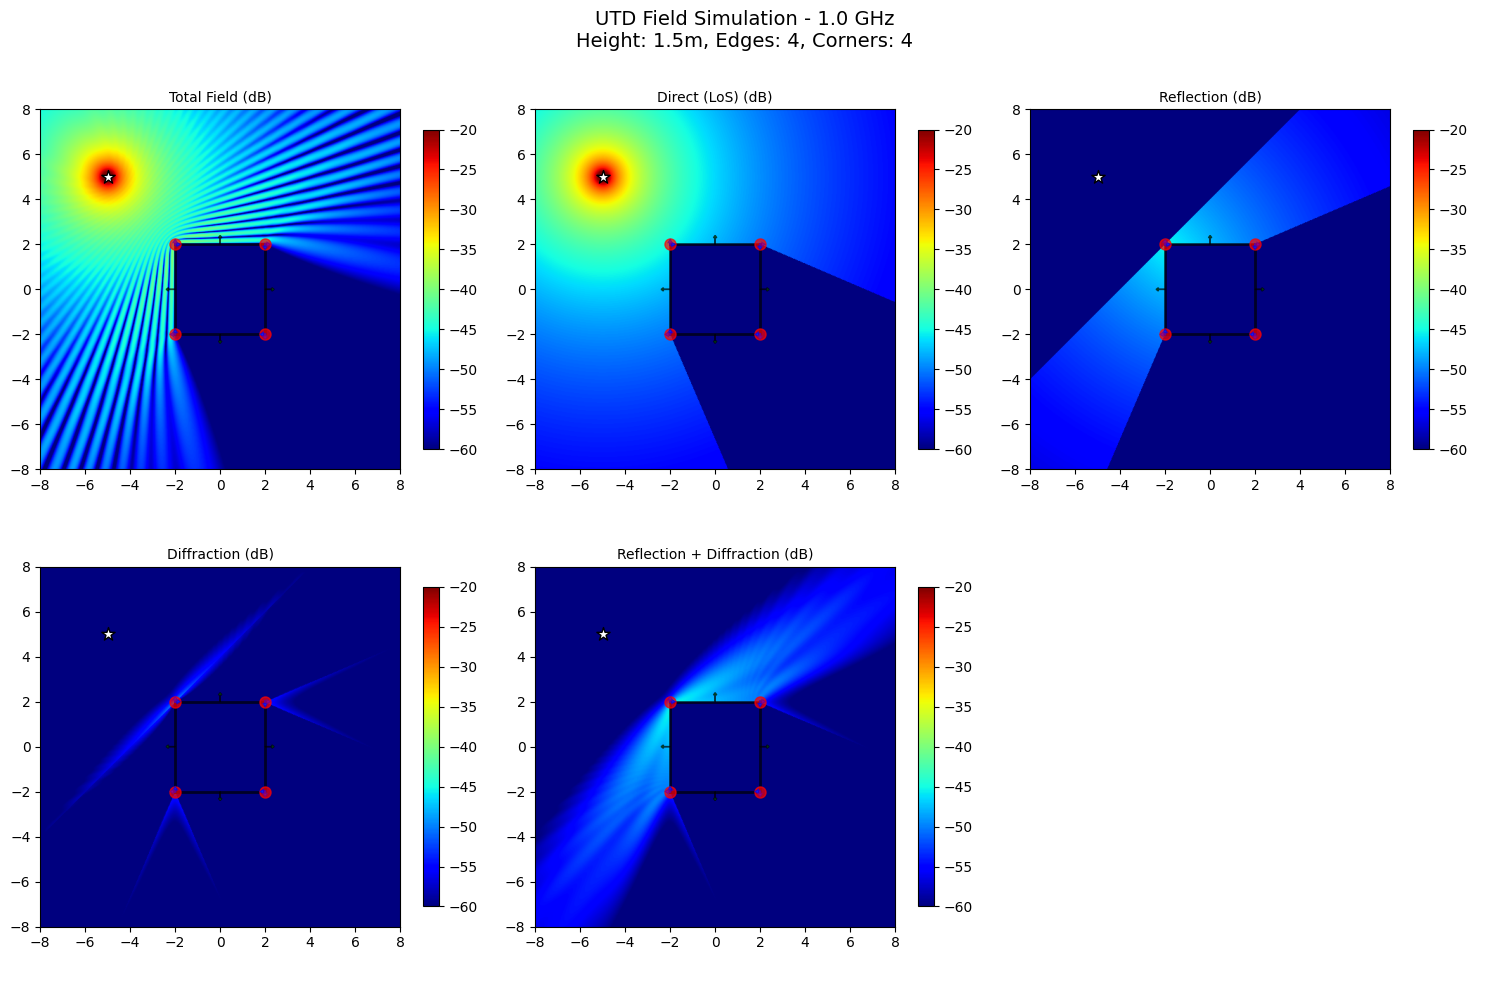

In [2]:
print("=" * 60)
print("Running mesh-based propagation simulation")
print("=" * 60)

# Mesh parameters (torch tensors)
center = torch.tensor([0.0, 0.0, 2.0], device='cuda')
size = torch.tensor(4.0, device='cuda')

# Create mesh
vertices, faces = create_cube_mesh(center=center, size=size)
scene = Scene(vertices, faces)
print(f"Mesh: vertices and faces created")

# Setup simulation parameters
freq = 1e9  # 1 GHz
tx_pos = torch.tensor([-5.0, 5.0, 1.5], device='cuda')
range_x, range_y = (-8, 8), (-8, 8)
grid_size = 512
n_rays = 10000000

max_reflections = 1
reflection_coef = 1.0

# Create tracer
tracer = Tracer(
    frequency=freq,
    scene=scene,
    reflection_n_rays=n_rays,
    reflection_max_bounces=max_reflections,
    reflection_coef=reflection_coef
)

start_time = time.time()

# Compute field distribution
result = tracer.trace(
    tx_pos=tx_pos,
    grid_size=grid_size,
    range_x=range_x,
    range_y=range_y
)
end_time = time.time()
print(f"[OK] Computed field distribution in {end_time - start_time:.5f} seconds")

# Plot results
fig = plot_mesh_2d(result, scene, freq, range_x, range_y)
os.makedirs('figures', exist_ok=True)
fig.savefig("figures/mesh_2d_detailed.png", dpi=150)
print("[OK] Figure saved to figures/mesh_2d_detailed.png")
plt.show()